In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uncertainties as un
import uncertainties.unumpy as unp

nom = unp.nominal_values
err = unp.std_devs

In [3]:
D_calcite = {
    'Mg': un.ufloat(0.014, 0.02),  # DMg from Mucci & Morse (1983) via Hasiuk 2010 (10.1016/j.gca.2010.07.030)
    'Sr': un.ufloat(7e-2, 2e-2),  # DSr from Morse & Bender (1990)
    'Na': un.ufloat(1e-4, 0.1e-4),  # DNa from Kawabata et al (2021; 10.1016/j.chemgeo.2020.119904)
    'B': un.ufloat(1e-3, 0.2e-3),  # DB (BT/DIC) from Uchikawa et al (2015)
}

In [21]:
dat = pd.read_pickle('data/vaterite_processed.pkl')

D_vaterite = {}
for el in D_calcite:
    if el in ['Mg', 'Sr']:
        ind = dat.metadata.Experiment.isin([el, 'Mg+Sr']).values
    elif el == 'Na':
        ind = np.ones(dat.shape[0], dtype=bool)
    else:
        ind = dat.metadata.Experiment.isin([el]).values
    
        
    D_vaterite[el] = np.nanmean(dat.vaterite.loc[ind, f'D_{el}'].values)
    
D_vaterite

{'Mg': 0.05289787319423289+/-0.026729946872871682,
 'Sr': 0.21349607579281327+/-0.08651520059355668,
 'Na': 4.487861802009029+/-0.7969436142071669,
 'B': 0.025355725450078626+/-0.0011481641690824344}

In [25]:
SW = {
    'Ca': 0.0102821,
    'Na': 0.4689674,
    'Mg': 0.0528171,
    'B': 432e-6,
    'Sr': 0.0000907
}

SW_ratios = {el: SW[el] / SW['Ca'] for el in SW}
SW_ratios.pop('Ca');
SW_ratios

{'Na': 45.61007965298917,
 'Mg': 5.136800848075782,
 'B': 0.04201476352107059,
 'Sr': 0.008821155211484034}

In [33]:
foram_ratio_ranges = {
    'Na': (4e-3, 7e-3),
    'Mg': (0.5e-3, 10e-3),
    'B': (10e-6, 100e-6),
    'Sr': (0.5e-3, 2e-3) 
}

In [44]:
multipliers = {
    'Na': 1e3,
    'Mg': 1e3,
    'B': 1e3,
    'Sr': 1e3
}

## Can double-fractionation explain foram geochemistry?

### Simple Double Fractionation

- Vaterite forms from seawater with composition set by vaterite $D_X$
- Vaterite dissolves and sets composition of internal liquid.
- Calcite forms from internal fluid with composition set by calcite $D_X$

$X/Ca_{V} = X/Ca_{SW} D_X^V D_X^C$


In [48]:
calc_foram = {el: SW_ratios[el] * D_calcite[el] * D_vaterite[el] for el in SW_ratios}

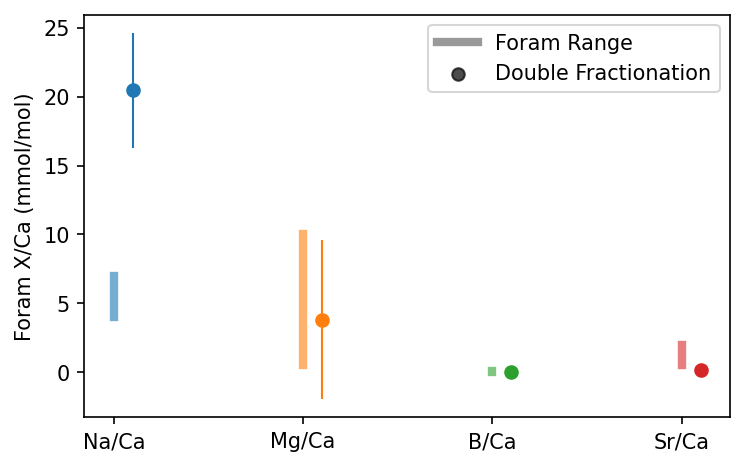

In [62]:
fig, ax = plt.subplots(constrained_layout=True)

els = list(SW_ratios.keys())

space = 0.1

for i, el in enumerate(els):
    m = np.array(multipliers[el])
    line = ax.plot([i,i], foram_ratio_ranges[el] * m, lw=4, alpha=0.6)
    
    c = line[0].get_color()
    
    ax.scatter(i + space, nom(calc_foram[el]) * m, color=c)
    ax.errorbar(i + space, nom(calc_foram[el]) * m, err(calc_foram[el]) * m, color=c, lw=0, elinewidth=1)
    
ax.set_xticks(np.arange(len(SW_ratios)))
ax.set_xticklabels([f'{el}/Ca' for el in els])

ax.set_ylabel('Foram X/Ca (mmol/mol)')

ax.plot([],[],color='k', lw=4, alpha=0.4, label='Foram Range')
ax.scatter([],[], color='k', alpha=0.7, label='Double Fractionation')
ax.legend()